# 🌾 Notebook 1 — Resize 512→256
**Input:** Pix2Pix Dataset v3.2 (512×512 patches)  
**Output:** 256×256 patches (same pairs, same alignment)  
**Method:** cv2.INTER_AREA (best quality downscale)


In [1]:
# from pathlib import Path

# base = Path('/kaggle/input/datasets/devanadi/pix2pix-dataset-preparation-v2-subuhh/output')

# print(f'Base exists: {base.exists()}')
# print()
# print('Full structure:')
# for f in sorted(base.rglob('*'))[:50]:
#     print(f'  {f.relative_to(base)}')

## 📦 Step 0 — Install & Import

In [2]:
import cv2, shutil, random, json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from datetime import datetime
print(f'Started: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')


Started: 2026-06-18 22:56:36


## ⚙️ Step 1 — Configuration

In [3]:
# ── Input (READ ONLY) ────────────────────────────────────────
BASE_INPUT = '/kaggle/input/datasets/devanadi/pix2pix-dataset-preparation-v2-subuhh/output'
INPUT_512  = f'{BASE_INPUT}/patches_512'

assert Path(INPUT_512).exists(), f'Cannot find: {INPUT_512}'
print(f'INPUT_512 found: {INPUT_512}')

# ── Output ────────────────────────────────────────────────────
OUTPUT_256   = '/kaggle/working/patches_256'
SPLITS       = ['train', 'val', 'test']
DOMAINS      = ['A', 'B']
TARGET_SIZE  = 256
SAVE_QUALITY = 95
RANDOM_SEED  = 42
random.seed(RANDOM_SEED)

print(f'INPUT  : {INPUT_512}')
print(f'OUTPUT : {OUTPUT_256}')
print(f'TARGET : {TARGET_SIZE}x{TARGET_SIZE}')

INPUT_512 found: /kaggle/input/datasets/devanadi/pix2pix-dataset-preparation-v2-subuhh/output/patches_512
INPUT  : /kaggle/input/datasets/devanadi/pix2pix-dataset-preparation-v2-subuhh/output/patches_512
OUTPUT : /kaggle/working/patches_256
TARGET : 256x256


## 🔍 Step 2 — Verify Input Paths & Count

In [4]:
def verify_input(input_512, splits, domains):
    print('Verifying input structure...')
    total = {}
    all_ok = True
    for split in splits:
        total[split] = {}
        for domain in domains:
            folder = Path(input_512)/split/domain
            if not folder.exists():
                print(f'  MISSING: {folder}')
                all_ok = False
                continue
            files = sorted(folder.glob('*.jpg'))
            total[split][domain] = len(files)
            print(f'  {split}/{domain}: {len(files):,} files')
    # Verify A and B counts match per split
    for split in splits:
        if 'A' in total[split] and 'B' in total[split]:
            if total[split]['A'] != total[split]['B']:
                print(f'  MISMATCH {split}: A={total[split]["A"]} B={total[split]["B"]}')
                all_ok = False
            else:
                print(f'  PAIRED {split}: {total[split]["A"]:,} pairs OK')
    print(f'Input verification: {"PASSED" if all_ok else "FAILED"}')
    return total, all_ok

input_counts, input_ok = verify_input(INPUT_512, SPLITS, DOMAINS)
assert input_ok, 'Fix input structure before continuing.'


Verifying input structure...
  train/A: 25,165 files
  train/B: 25,165 files
  val/A: 5,280 files
  val/B: 5,280 files
  test/A: 5,464 files
  test/B: 5,464 files
  PAIRED train: 25,165 pairs OK
  PAIRED val: 5,280 pairs OK
  PAIRED test: 5,464 pairs OK
Input verification: PASSED


## 🔄 Step 3 — Resize A/ and B/ Together
> INTER_AREA = best quality for downscaling  
> A and B resized together = alignment preserved  
> Same filename = pairing preserved

In [5]:
def resize_split(input_512, output_256, split, target_size, quality):
    """
    Resize all patches in one split.
    A and B processed together by filename to ensure pairing.
    """
    dir_a_in  = Path(input_512)  / split / 'A'
    dir_b_in  = Path(input_512)  / split / 'B'
    dir_a_out = Path(output_256) / split / 'A'
    dir_b_out = Path(output_256) / split / 'B'
    dir_a_out.mkdir(parents=True, exist_ok=True)
    dir_b_out.mkdir(parents=True, exist_ok=True)

    files_a = sorted(dir_a_in.glob('*.jpg'))
    saved   = 0
    errors  = 0
    missing_b = 0
    params = [cv2.IMWRITE_JPEG_QUALITY, quality]

    for f_a in tqdm(files_a, desc=f'Resize {split}'):
        f_b = dir_b_in / f_a.name  # same filename = paired

        if not f_b.exists():
            missing_b += 1
            continue

        try:
            # Read both
            img_a = cv2.imread(str(f_a))
            img_b = cv2.imread(str(f_b), cv2.IMREAD_GRAYSCALE)

            if img_a is None or img_b is None:
                errors += 1; continue

            # Resize both with INTER_AREA (best for downscale)
            img_a_256 = cv2.resize(img_a, (target_size, target_size),
                                   interpolation=cv2.INTER_AREA)
            img_b_256 = cv2.resize(img_b, (target_size, target_size),
                                   interpolation=cv2.INTER_AREA)

            # Save both with same filename
            cv2.imwrite(str(dir_a_out / f_a.name), img_a_256, params)
            cv2.imwrite(str(dir_b_out / f_a.name), img_b_256, params)
            saved += 1

        except Exception as e:
            errors += 1
            continue

    print(f'  {split}: saved={saved:,} missing_b={missing_b} errors={errors}')
    return saved, errors


resize_results = {}
for split in SPLITS:
    saved, errors = resize_split(INPUT_512, OUTPUT_256, split, TARGET_SIZE, SAVE_QUALITY)
    resize_results[split] = {'saved': saved, 'errors': errors}

print('\nResize complete!')


Resize train: 100%|██████████| 25165/25165 [09:59<00:00, 41.96it/s]


  train: saved=25,165 missing_b=0 errors=0


Resize val: 100%|██████████| 5280/5280 [01:53<00:00, 46.54it/s]


  val: saved=5,280 missing_b=0 errors=0


Resize test: 100%|██████████| 5464/5464 [01:58<00:00, 46.24it/s]

  test: saved=5,464 missing_b=0 errors=0

Resize complete!


## ✅ Step 4 — Verify Output Pairs

In [6]:
def verify_output_pairs(output_256, splits):
    print('Verifying output pairs...')
    all_ok = True
    for split in splits:
        dir_a = Path(output_256)/split/'A'
        dir_b = Path(output_256)/split/'B'
        files_a = set(f.name for f in dir_a.glob('*.jpg'))
        files_b = set(f.name for f in dir_b.glob('*.jpg'))
        only_a = files_a - files_b
        only_b = files_b - files_a
        paired = files_a & files_b
        ok = (len(only_a)==0 and len(only_b)==0 and len(paired)>0)
        if not ok: all_ok = False
        status = 'OK' if ok else 'FAIL'
        print(f'  [{status}] {split}: A={len(files_a):,} B={len(files_b):,} paired={len(paired):,}'
              + (f' only_A={len(only_a)}' if only_a else '')
              + (f' only_B={len(only_b)}' if only_b else ''))
        # Verify actual image size
        if paired:
            sample = list(paired)[:3]
            for fname in sample:
                img_a = cv2.imread(str(dir_a/fname))
                img_b = cv2.imread(str(dir_b/fname))
                if img_a is not None and img_b is not None:
                    ha,wa = img_a.shape[:2]
                    hb,wb = img_b.shape[:2]
                    size_ok = (ha==256 and wa==256 and hb==256 and wb==256)
                    if not size_ok:
                        print(f'    SIZE ERROR: A={wa}x{ha} B={wb}x{hb}')
                        all_ok = False
    print(f'Output verification: {"PASSED" if all_ok else "FAILED"}')
    return all_ok

output_ok = verify_output_pairs(OUTPUT_256, SPLITS)


Verifying output pairs...
  [OK] train: A=25,165 B=25,165 paired=25,165
  [OK] val: A=5,280 B=5,280 paired=5,280
  [OK] test: A=5,464 B=5,464 paired=5,464
Output verification: PASSED


## 👀 Step 5 — Visual Check RGB vs NDVI 256×256

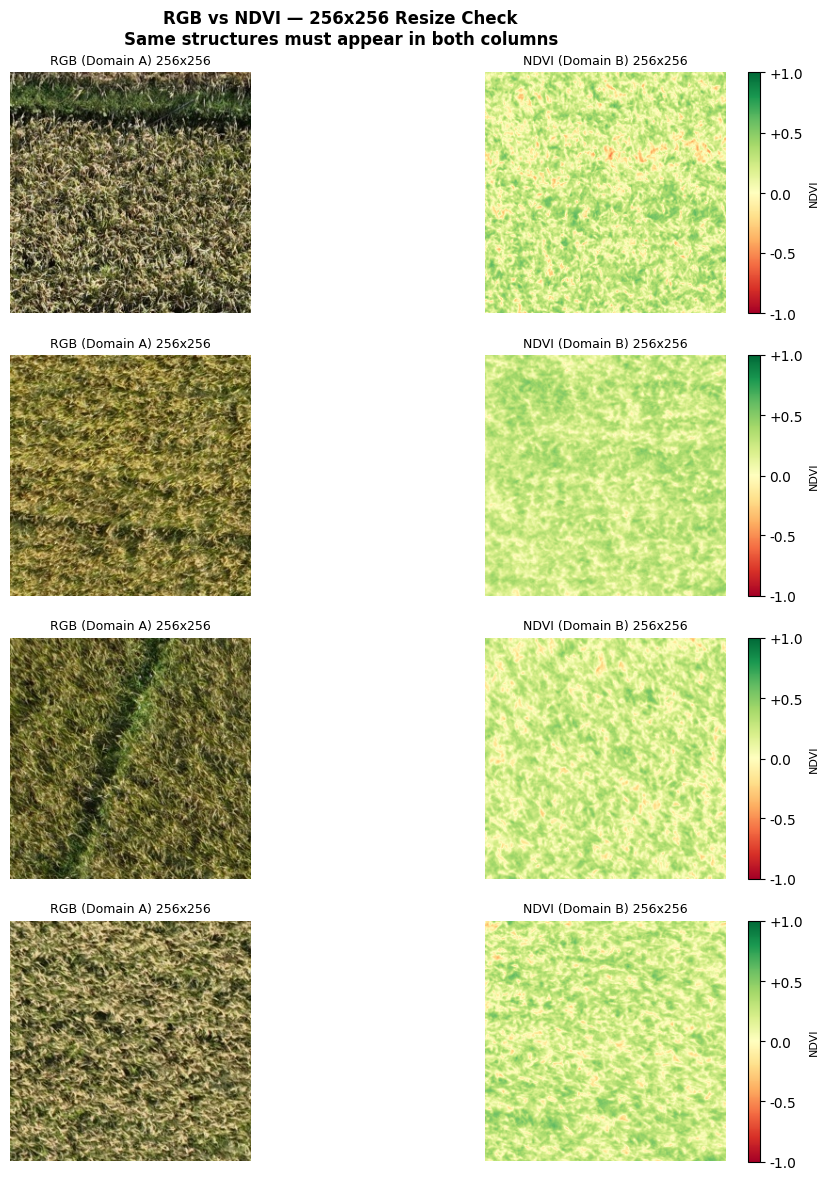

No blurriness + same structures = resize successful!


In [7]:
def visual_check_256(output_256, n_samples=4):
    dir_a = Path(output_256)/'train'/'A'
    dir_b = Path(output_256)/'train'/'B'
    files = sorted(dir_a.glob('*.jpg'))
    samples = random.sample(files, min(n_samples, len(files)))
    fig, axes = plt.subplots(n_samples, 2, figsize=(10, n_samples*3))
    fig.suptitle('RGB vs NDVI — 256x256 Resize Check\nSame structures must appear in both columns',
                 fontsize=12, fontweight='bold')
    for i, f_a in enumerate(samples):
        f_b = dir_b/f_a.name
        img_a = cv2.cvtColor(cv2.imread(str(f_a)), cv2.COLOR_BGR2RGB)
        img_b = cv2.imread(str(f_b), cv2.IMREAD_GRAYSCALE) if f_b.exists() \
                else np.zeros((256,256), np.uint8)
        axes[i][0].imshow(img_a)
        axes[i][0].set_title('RGB (Domain A) 256x256', fontsize=9)
        axes[i][0].axis('off')
        im = axes[i][1].imshow(img_b, cmap='RdYlGn', vmin=0, vmax=255)
        axes[i][1].set_title('NDVI (Domain B) 256x256', fontsize=9)
        axes[i][1].axis('off')
        cbar = plt.colorbar(im, ax=axes[i][1], fraction=0.046, pad=0.04)
        cbar.set_ticks([0,64,127,191,255])
        cbar.set_ticklabels(['-1.0','-0.5','0.0','+0.5','+1.0'])
        cbar.set_label('NDVI', fontsize=8)
    plt.tight_layout()
    plt.savefig('/kaggle/working/visual_check_256.png', dpi=100, bbox_inches='tight')
    plt.show()
    print('No blurriness + same structures = resize successful!')

visual_check_256(OUTPUT_256)


## 📋 Step 6 — Final Summary

In [8]:
print('='*50)
print('RESIZE SUMMARY 512 -> 256')
print('='*50)
for split in SPLITS:
    dir_a = Path(OUTPUT_256)/split/'A'
    count = len(list(dir_a.glob('*.jpg')))
    print(f'{split:5s}: {count:,} pairs')
print(f'\nOutput: {OUTPUT_256}/')
print('  train/A/  B/')
print('  val/A/    B/')
print('  test/A/   B/')
print('\nReady for Pix2Pix training notebook!')
# Save manifest
manifest = {'source': INPUT_512, 'output': OUTPUT_256,
            'target_size': TARGET_SIZE, 'interpolation': 'INTER_AREA',
            'counts': {s: len(list((Path(OUTPUT_256)/s/'A').glob('*.jpg'))) for s in SPLITS}}
with open('/kaggle/working/resize_manifest.json','w') as f:
    json.dump(manifest, f, indent=2)
print('Manifest saved.')


RESIZE SUMMARY 512 -> 256
train: 25,165 pairs
val  : 5,280 pairs
test : 5,464 pairs

Output: /kaggle/working/patches_256/
  train/A/  B/
  val/A/    B/
  test/A/   B/

Ready for Pix2Pix training notebook!
Manifest saved.
